In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [2]:
DATA_PATH = Path("../data/processed/student_performance.csv")
MODEL_PATH = Path("../models/random_forest.pkl")
METRICS_PATH = Path("../models/model_metrics.json")

df = pd.read_csv(DATA_PATH)
df.head()

,student_id,day,topic,exercises_attempted,exercises_solved_correctly,hints_used,time_spent_minutes,previous_eval_score,today_eval_score,at_risk
0,1,1,variables,4,3,8,35,12.91,16.18,False
1,1,2,conditions,3,0,6,31,16.18,6.49,True
2,1,3,loops,5,4,4,117,6.49,11.26,False
3,1,4,lists,5,2,0,64,11.26,12.59,False
4,1,5,functions,3,0,7,65,12.59,2.45,True


In [3]:
print(df.shape)
print(df["topic"].nunique())
print(df["at_risk"].value_counts(normalize=True))

(264, 10)
11
at_risk
True     0.537879
False    0.462121
Name: proportion, dtype: float64


In [4]:
feature_cols = [
    "day",
    "topic",
    "exercises_attempted",
    "exercises_solved_correctly",
    "hints_used",
    "time_spent_minutes",
    "previous_eval_score",
]

target_col = "today_eval_score"

X = df[feature_cols]
y = df[target_col]

In [5]:
y_at_risk = (y < 10).astype(int)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(X_train.shape, X_test.shape)

(211, 7) (53, 7)


In [7]:
numeric_features = [
    "day",
    "exercises_attempted",
    "exercises_solved_correctly",
    "hints_used",
    "time_spent_minutes",
    "previous_eval_score",
]

categorical_features = ["topic"]

In [8]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [9]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

In [10]:
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5

# baseline_rmse = mean_squared_error(y_test, baseline_pred, squared=False)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE :", baseline_mae)
print("Baseline R2  :", baseline_r2)

Baseline RMSE: 2.7283381736007977
Baseline MAE : 2.200100258124104
Baseline R2  : 0.8038419282150413


In [11]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [12]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

In [13]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more abo

In [14]:
print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV score: -2.510652615128147


In [15]:
best_rf = grid_search.best_estimator_
rf_pred = best_rf.predict(X_test)

# rf_rmse = mean_squared_error(y_test, rf_pred, squared=False)
rf_rmse = mean_squared_error(y_test, rf_pred,) ** 0.5
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("RF RMSE:", rf_rmse)
print("RF MAE :", rf_mae)
print("RF R2  :", rf_r2)

RF RMSE: 2.6505290909903225
RF MAE : 2.149844264135123
RF R2  : 0.8148707954041362


In [16]:
comparison = pd.DataFrame(
    {
        "model": ["LinearRegression", "RandomForest"],
        "rmse": [baseline_rmse, rf_rmse],
        "mae": [baseline_mae, rf_mae],
        "r2": [baseline_r2, rf_r2],
    }
)

comparison

,model,rmse,mae,r2
0,LinearRegression,2.728338,2.200100,0.803842
1,RandomForest,2.650529,2.149844,0.814871


In [17]:
y_test_at_risk = (y_test < 10).astype(int)
rf_pred_at_risk = (rf_pred < 10).astype(int)
baseline_pred_at_risk = (baseline_pred < 10).astype(int)

In [18]:
baseline_recall = recall_score(y_test_at_risk, baseline_pred_at_risk)
rf_recall = recall_score(y_test_at_risk, rf_pred_at_risk)

print("Baseline at-risk recall:", baseline_recall)
print("RF at-risk recall:", rf_recall)

Baseline at-risk recall: 0.9615384615384616
RF at-risk recall: 1.0


In [19]:
cm = confusion_matrix(y_test_at_risk, rf_pred_at_risk)
cm

array([[23,  4],
       [ 0, 26]])

In [20]:
print(classification_report(y_test_at_risk, rf_pred_at_risk, target_names=["not_at_risk", "at_risk"]))


              precision    recall  f1-score   support

 not_at_risk       1.00      0.85      0.92        27
     at_risk       0.87      1.00      0.93        26

    accuracy                           0.92        53
   macro avg       0.93      0.93      0.92        53
weighted avg       0.93      0.92      0.92        53



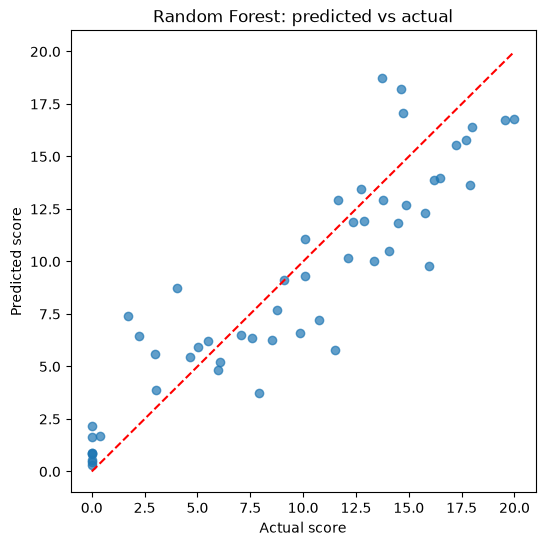

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.7)
plt.plot([0, 20], [0, 20], "r--")
plt.xlabel("Actual score")
plt.ylabel("Predicted score")
plt.title("Random Forest: predicted vs actual")
plt.show()

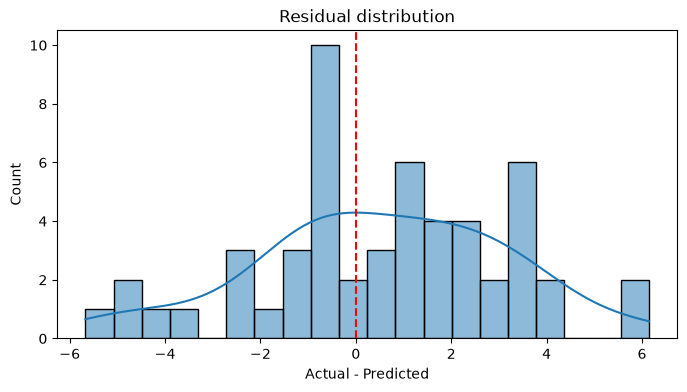

In [22]:
residuals = y_test - rf_pred

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=20, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Residual distribution")
plt.xlabel("Actual - Predicted")
plt.show()

In [23]:
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame(
        {"feature": feature_names, "importance": importances}
    )
    .sort_values("importance", ascending=False)
)

importance_df.head(15)

,feature,importance
2,num__exercises_solved_correctly,0.459206
5,num__previous_eval_score,0.374860
3,num__hints_used,0.075351
1,num__exercises_attempted,0.043637
4,num__time_spent_minutes,0.024467
0,num__day,0.011884
12,cat__topic_lists,0.003575
9,cat__topic_files,0.001337
14,cat__topic_oop_classes,0.001033
8,cat__topic_error_handling,0.000855


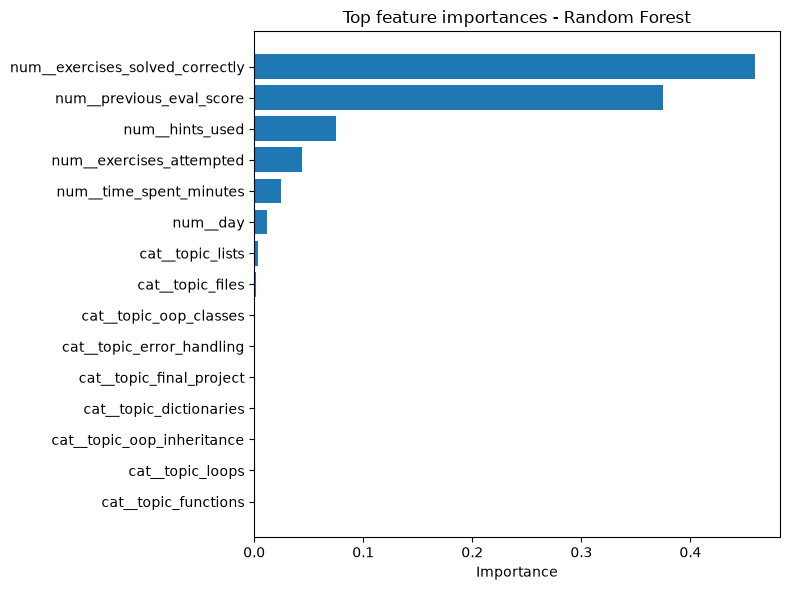

In [24]:
top_n = 15
top_importance = importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title("Top feature importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [25]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_rf, MODEL_PATH)
print(f"Saved model to: {MODEL_PATH}")

Saved model to: ../models/random_forest.pkl


In [26]:
metrics_payload = {
    "baseline": {
        "rmse": float(baseline_rmse),
        "mae": float(baseline_mae),
        "r2": float(baseline_r2),
        "at_risk_recall": float(baseline_recall),
    },
    "random_forest": {
        "rmse": float(rf_rmse),
        "mae": float(rf_mae),
        "r2": float(rf_r2),
        "at_risk_recall": float(rf_recall),
        "best_params": grid_search.best_params_,
    },
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

metrics_payload

{'baseline': {'rmse': 2.7283381736007977,
  'mae': 2.200100258124104,
  'r2': 0.8038419282150413,
  'at_risk_recall': 0.9615384615384616},
 'random_forest': {'rmse': 2.6505290909903225,
  'mae': 2.149844264135123,
  'r2': 0.8148707954041362,
  'at_risk_recall': 1.0,
  'best_params': {'model__max_depth': 10,
   'model__min_samples_leaf': 2,
   'model__min_samples_split': 2,
   'model__n_estimators': 300}}}

## Phase 2 Conclusions

1. **Baseline vs Random Forest:** Random Forest did outperform Linear Regression.
2. **Final regression metrics:** RMSE = 2.650529, MAE = 2.149844, R² = 0.814871.
3. **At-risk detection:** Recall = 1.0, which means the model catches 100% of struggling students.
4. **Main drivers:** The most important features were exercises_solved_correctly, previous_eval_score, and hints_used	.
5. **PoC verdict:** The model is ready for integration into the Performance Analyzer agent because it beats the baseline, catches all at-risk students on the test set, and is saved as a reusable pipeline.